In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [1]:
results_loc = "/data/home/natant/Negatives/Runs/Review_calibration/calibration_results_take_2.pkl"

In [4]:
results_df = pd.read_pickle(results_loc)

In [5]:
results_df

,TF,cross_val,neg_type,cell_line,val_best_thresholds_MCC,val_best_thresholds_Precision,val_best_thresholds_Specificity,val_best_thresholds_Accuracy,val_best_thresholds_Recall,val_best_scores_MCC,...,test_scores_HQ_Specificity,test_scores_HQ_Accuracy,test_scores_HQ_Recall,test_scores_HQ_adjusted_AUROC,test_scores_HQ_adjusted_AvP,test_scores_HQ_adjusted_MCC,test_scores_HQ_adjusted_Precision,test_scores_HQ_adjusted_Specificity,test_scores_HQ_adjusted_Accuracy,test_scores_HQ_adjusted_Recall
0,TCF12,0,dinucl-sampled,GM12878,0.22,0.38,0.39,0.15,0.01,tensor(0.5151),...,tensor(1.),tensor(0.4360),tensor(0.9988),tensor(0.7351),tensor(0.1047),tensor(0.2040),tensor(0.1344),tensor(1.),tensor(0.9443),tensor(0.9988)
1,TCF12,0,neighbors,GM12878,0.51,0.96,0.96,0.50,0.01,tensor(0.4877),...,tensor(0.9999),tensor(0.7237),tensor(1.),tensor(0.7801),tensor(0.2176),tensor(0.2436),tensor(1.),tensor(1.),tensor(0.9443),tensor(1.)
2,TCF12,0,celltype,GM12878,0.70,0.98,0.98,0.69,0.01,tensor(0.3740),...,tensor(0.9999),tensor(0.7207),tensor(1.),tensor(0.7208),tensor(0.1919),tensor(0.2098),tensor(0.6667),tensor(1.0000),tensor(0.9445),tensor(1.)
3,TCF12,0,shuffled,GM12878,0.46,0.56,0.58,0.39,0.01,tensor(0.7798),...,tensor(1.),tensor(0.2612),tensor(0.9982),tensor(0.5605),tensor(0.0604),tensor(0.0750),tensor(0.0702),tensor(1.),tensor(0.9443),tensor(0.9982)
4,TCF12,0,dinucl-shuffled,GM12878,0.43,0.99,0.99,0.42,0.01,tensor(0.5031),...,tensor(0.9995),tensor(0.6558),tensor(1.),tensor(0.7458),tensor(0.1721),tensor(0.2125),tensor(0.3277),tensor(0.9995),tensor(0.9440),tensor(1.)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,ZZZ3,4,dinucl-sampled,GM12878,0.55,0.65,0.65,0.55,0.01,tensor(0.5480),...,tensor(1.0000),tensor(0.7512),tensor(1.),tensor(0.8168),tensor(0.3395),tensor(0.4906),tensor(0.8182),tensor(1.),tensor(0.9982),tensor(1.)
896,ZZZ3,4,neighbors,GM12878,0.51,0.93,0.93,0.51,0.01,tensor(0.6065),...,tensor(1.),tensor(0.9980),tensor(1.),tensor(0.8258),tensor(0.5483),tensor(0.6529),tensor(1.),tensor(1.),tensor(0.9987),tensor(1.)
897,ZZZ3,4,celltype,GM12878,0.46,0.86,0.86,0.46,0.01,tensor(0.5540),...,tensor(1.0000),tensor(0.9235),tensor(1.),tensor(0.8176),tensor(0.4286),tensor(0.5530),tensor(1.),tensor(1.),tensor(0.9985),tensor(1.)
898,ZZZ3,4,shuffled,GM12878,0.43,0.43,0.43,0.42,0.01,tensor(0.6875),...,tensor(0.9950),tensor(0.9821),tensor(1.),tensor(0.7912),tensor(0.4488),tensor(0.5419),tensor(0.6541),tensor(1.),tensor(0.9983),tensor(1.)


In [6]:
results_df.columns

Index(['TF', 'cross_val', 'neg_type', 'cell_line', 'val_best_thresholds_MCC',
       'val_best_thresholds_Precision', 'val_best_thresholds_Specificity',
       'val_best_thresholds_Accuracy', 'val_best_thresholds_Recall',
       'val_best_scores_MCC', 'val_best_scores_Precision',
       'val_best_scores_Specificity', 'val_best_scores_Accuracy',
       'val_best_scores_Recall', 'val_best_thresholds_HQ_MCC',
       'val_best_thresholds_HQ_Precision',
       'val_best_thresholds_HQ_Specificity', 'val_best_thresholds_HQ_Accuracy',
       'val_best_thresholds_HQ_Recall', 'val_best_scores_HQ_MCC',
       'val_best_scores_HQ_Precision', 'val_best_scores_HQ_Specificity',
       'val_best_scores_HQ_Accuracy', 'val_best_scores_HQ_Recall',
       'test_scores_AUROC', 'test_scores_AvP', 'test_scores_MCC',
       'test_scores_Precision', 'test_scores_Specificity',
       'test_scores_Accuracy', 'test_scores_Recall', 'test_scores_HQ_AUROC',
       'test_scores_HQ_AvP', 'test_scores_HQ_MCC', 'test_sc

In [7]:
results_df["val_best_scores_HQ_Accuracy"]

0      tensor(0.9438)
1      tensor(0.9439)
2      tensor(0.9440)
3      tensor(0.9438)
4      tensor(0.9434)
            ...      
895    tensor(0.9984)
896    tensor(0.9989)
897    tensor(0.9987)
898    tensor(0.9983)
899    tensor(0.9981)
Name: val_best_scores_HQ_Accuracy, Length: 900, dtype: object

In [8]:
results_df["test_scores_HQ_adjusted_Accuracy"]

0      tensor(0.9443)
1      tensor(0.9443)
2      tensor(0.9445)
3      tensor(0.9443)
4      tensor(0.9440)
            ...      
895    tensor(0.9982)
896    tensor(0.9987)
897    tensor(0.9985)
898    tensor(0.9983)
899    tensor(0.9979)
Name: test_scores_HQ_adjusted_Accuracy, Length: 900, dtype: object

In [9]:
def plot_metric_comparison(df, metric='MCC'):
    """
    Plot comparison of a metric across normal, HQ, and HQ_adjusted versions on the same plot.
    
    Parameters:
    df: DataFrame containing the results
    metric: str, the metric to plot (e.g., 'MCC', 'Precision', 'AUROC')
    """
    # Extract the three versions of the metric
    normal_col = f'test_scores_{metric}'
    hq_col = f'test_scores_HQ_{metric}'
    hq_adjusted_col = f'test_scores_HQ_adjusted_{metric}'
    
    # Convert tensor values to float
    df_plot = df.copy()
    for col in [normal_col, hq_col, hq_adjusted_col]:
        df_plot[col] = df_plot[col].apply(lambda x: x.item() if isinstance(x, torch.Tensor) else x)
    
    # Create single figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get unique neg_types for consistent ordering
    neg_types = df_plot['neg_type'].unique()
    
    # Prepare positions for boxplots
    positions_normal = []
    positions_hq = []
    positions_hq_adjusted = []
    
    width = 0.25
    for i, nt in enumerate(neg_types):
        base_pos = i * 1.0
        positions_normal.append(base_pos - width)
        positions_hq.append(base_pos)
        positions_hq_adjusted.append(base_pos + width)
    
    # Prepare data for boxplots
    data_normal = [df_plot[df_plot['neg_type'] == nt][normal_col].values for nt in neg_types]
    data_hq = [df_plot[df_plot['neg_type'] == nt][hq_col].values for nt in neg_types]
    data_hq_adjusted = [df_plot[df_plot['neg_type'] == nt][hq_adjusted_col].values for nt in neg_types]
    
    # Plot boxplots with different colors
    bp1 = ax.boxplot(data_normal, positions=positions_normal, widths=width, patch_artist=True, label='Normal')
    bp2 = ax.boxplot(data_hq, positions=positions_hq, widths=width, patch_artist=True, label='HQ')
    bp3 = ax.boxplot(data_hq_adjusted, positions=positions_hq_adjusted, widths=width, patch_artist=True, label='HQ Adjusted')
    
    # Color the boxplots
    for patch in bp1['boxes']:
        patch.set_facecolor('lightblue')
    for patch in bp2['boxes']:
        patch.set_facecolor('lightgreen')
    for patch in bp3['boxes']:
        patch.set_facecolor('lightcoral')
    
    # Set labels and title
    ax.set_xticks([i * 1.0 for i in range(len(neg_types))])
    ax.set_xticklabels(neg_types, rotation=45, ha='right')
    ax.set_xlabel('Negative Type')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison: Normal vs HQ vs HQ Adjusted')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [18]:
results_df

,TF,cross_val,neg_type,cell_line,val_best_thresholds_MCC,val_best_thresholds_Precision,val_best_thresholds_Specificity,val_best_thresholds_Accuracy,val_best_thresholds_Recall,val_best_scores_MCC,...,test_scores_HQ_Specificity,test_scores_HQ_Accuracy,test_scores_HQ_Recall,test_scores_HQ_adjusted_AUROC,test_scores_HQ_adjusted_AvP,test_scores_HQ_adjusted_MCC,test_scores_HQ_adjusted_Precision,test_scores_HQ_adjusted_Specificity,test_scores_HQ_adjusted_Accuracy,test_scores_HQ_adjusted_Recall
0,TCF12,0,dinucl-sampled,GM12878,0.22,0.38,0.39,0.15,0.01,tensor(0.5151),...,tensor(1.),tensor(0.4360),tensor(0.9988),tensor(0.7351),tensor(0.1047),tensor(0.2040),tensor(0.1344),tensor(1.),tensor(0.9443),tensor(0.9988)
1,TCF12,0,neighbors,GM12878,0.51,0.96,0.96,0.50,0.01,tensor(0.4877),...,tensor(0.9999),tensor(0.7237),tensor(1.),tensor(0.7801),tensor(0.2176),tensor(0.2436),tensor(1.),tensor(1.),tensor(0.9443),tensor(1.)
2,TCF12,0,celltype,GM12878,0.70,0.98,0.98,0.69,0.01,tensor(0.3740),...,tensor(0.9999),tensor(0.7207),tensor(1.),tensor(0.7208),tensor(0.1919),tensor(0.2098),tensor(0.6667),tensor(1.0000),tensor(0.9445),tensor(1.)
3,TCF12,0,shuffled,GM12878,0.46,0.56,0.58,0.39,0.01,tensor(0.7798),...,tensor(1.),tensor(0.2612),tensor(0.9982),tensor(0.5605),tensor(0.0604),tensor(0.0750),tensor(0.0702),tensor(1.),tensor(0.9443),tensor(0.9982)
4,TCF12,0,dinucl-shuffled,GM12878,0.43,0.99,0.99,0.42,0.01,tensor(0.5031),...,tensor(0.9995),tensor(0.6558),tensor(1.),tensor(0.7458),tensor(0.1721),tensor(0.2125),tensor(0.3277),tensor(0.9995),tensor(0.9440),tensor(1.)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,ZZZ3,4,dinucl-sampled,GM12878,0.55,0.65,0.65,0.55,0.01,tensor(0.5480),...,tensor(1.0000),tensor(0.7512),tensor(1.),tensor(0.8168),tensor(0.3395),tensor(0.4906),tensor(0.8182),tensor(1.),tensor(0.9982),tensor(1.)
896,ZZZ3,4,neighbors,GM12878,0.51,0.93,0.93,0.51,0.01,tensor(0.6065),...,tensor(1.),tensor(0.9980),tensor(1.),tensor(0.8258),tensor(0.5483),tensor(0.6529),tensor(1.),tensor(1.),tensor(0.9987),tensor(1.)
897,ZZZ3,4,celltype,GM12878,0.46,0.86,0.86,0.46,0.01,tensor(0.5540),...,tensor(1.0000),tensor(0.9235),tensor(1.),tensor(0.8176),tensor(0.4286),tensor(0.5530),tensor(1.),tensor(1.),tensor(0.9985),tensor(1.)
898,ZZZ3,4,shuffled,GM12878,0.43,0.43,0.43,0.42,0.01,tensor(0.6875),...,tensor(0.9950),tensor(0.9821),tensor(1.),tensor(0.7912),tensor(0.4488),tensor(0.5419),tensor(0.6541),tensor(1.),tensor(0.9983),tensor(1.)


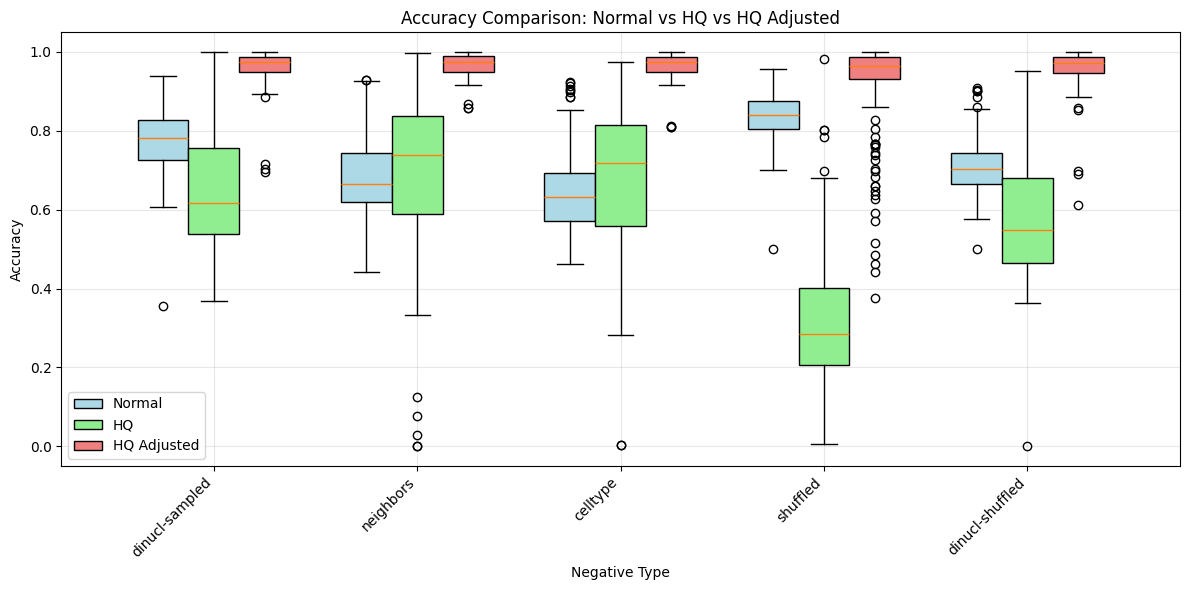

In [10]:
# Plot MCC comparison across normal, HQ, and HQ_adjusted versions
plot_metric_comparison(results_df, metric='Accuracy')

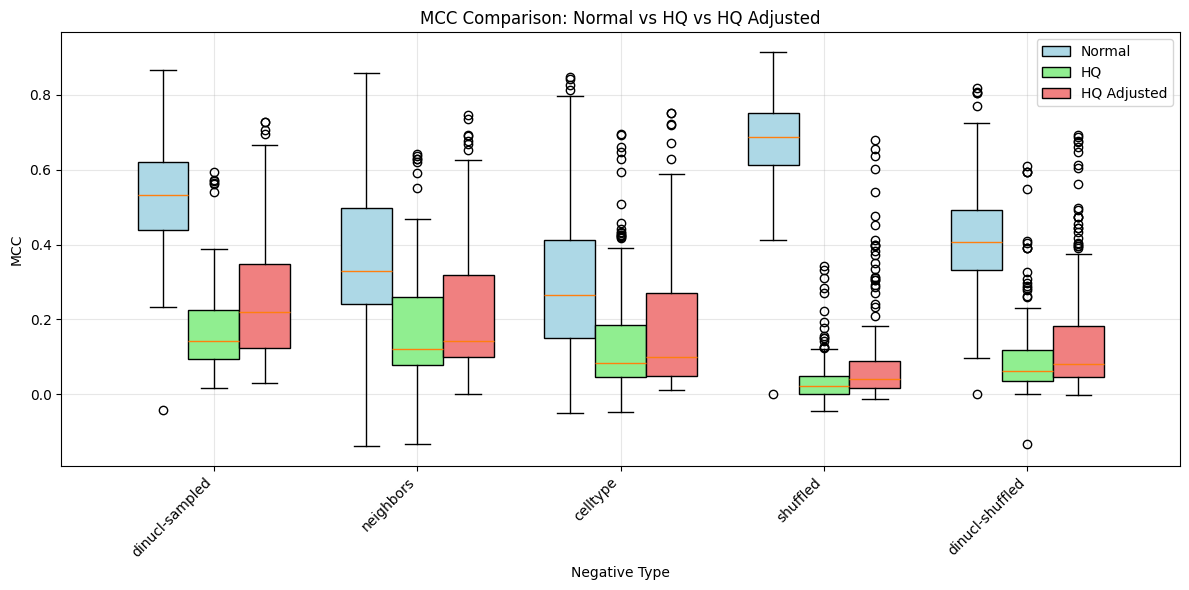

In [11]:
# Plot MCC comparison across normal, HQ, and HQ_adjusted versions
plot_metric_comparison(results_df, metric='MCC')

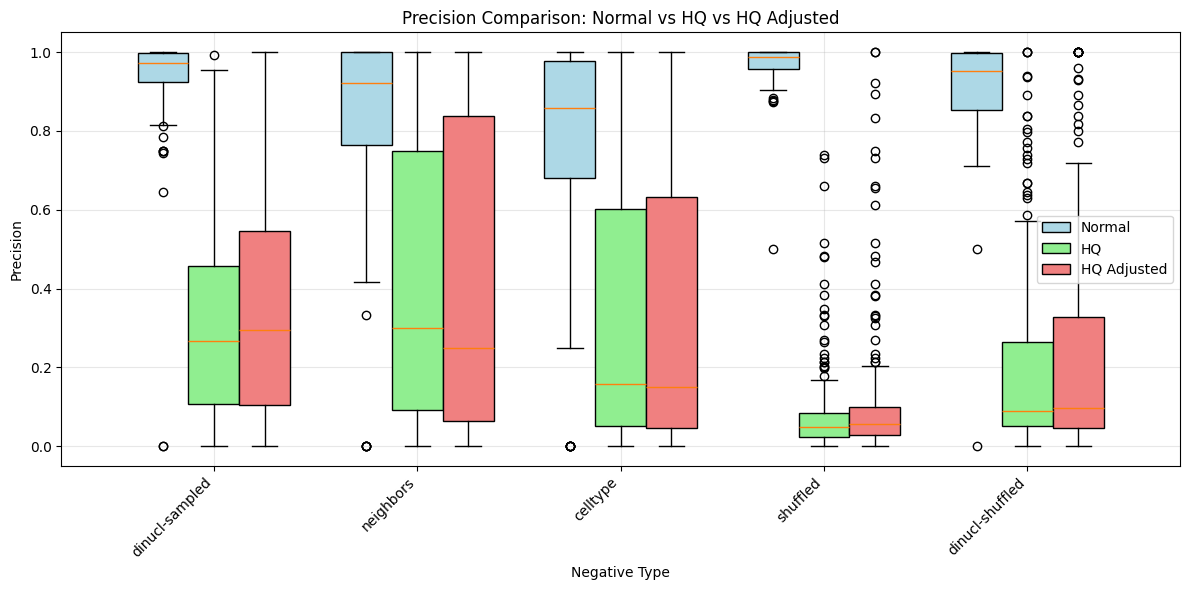

In [12]:
# Plot MCC comparison across normal, HQ, and HQ_adjusted versions
plot_metric_comparison(results_df, metric='Precision')

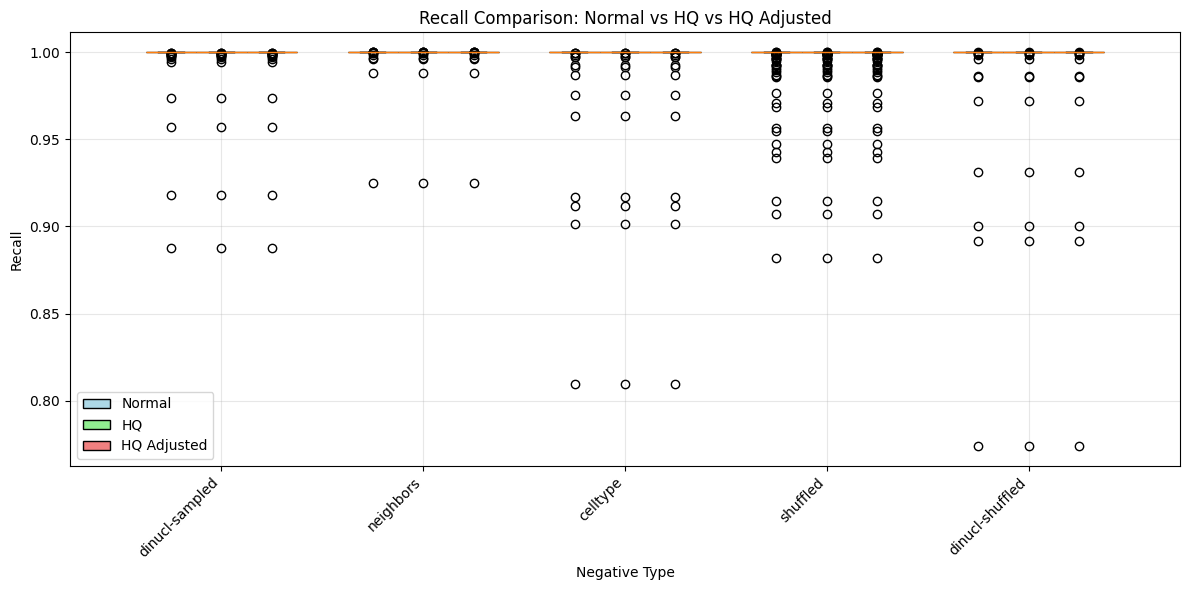

In [14]:
# Plot MCC comparison across normal, HQ, and HQ_adjusted versions
plot_metric_comparison(results_df, metric='Recall')

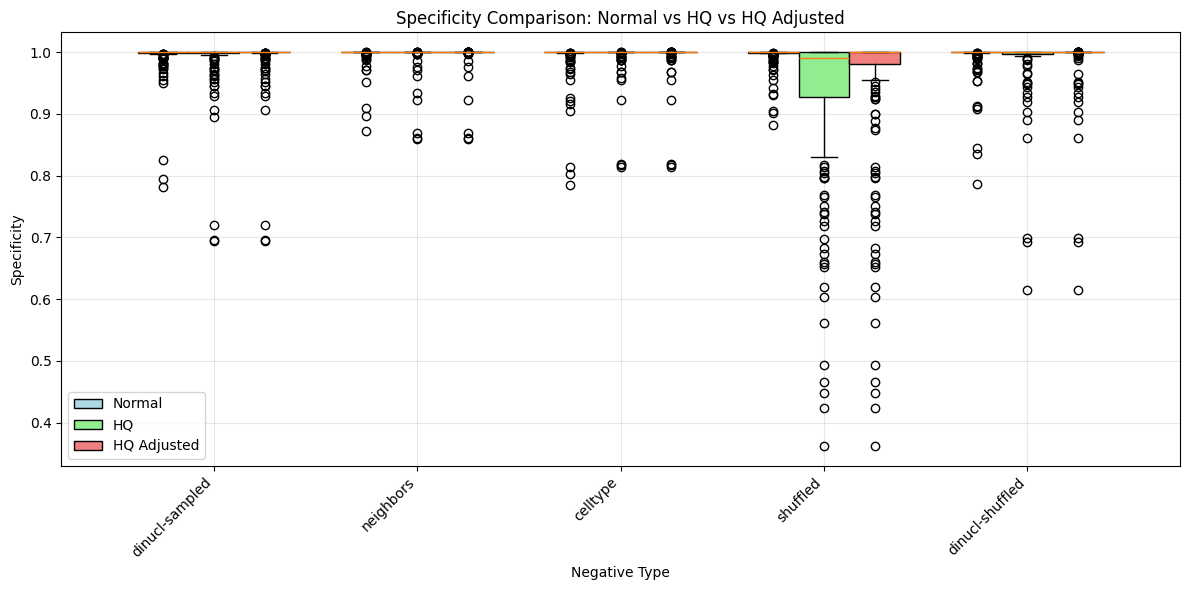

In [15]:
# Plot MCC comparison across normal, HQ, and HQ_adjusted versions
plot_metric_comparison(results_df, metric='Specificity')

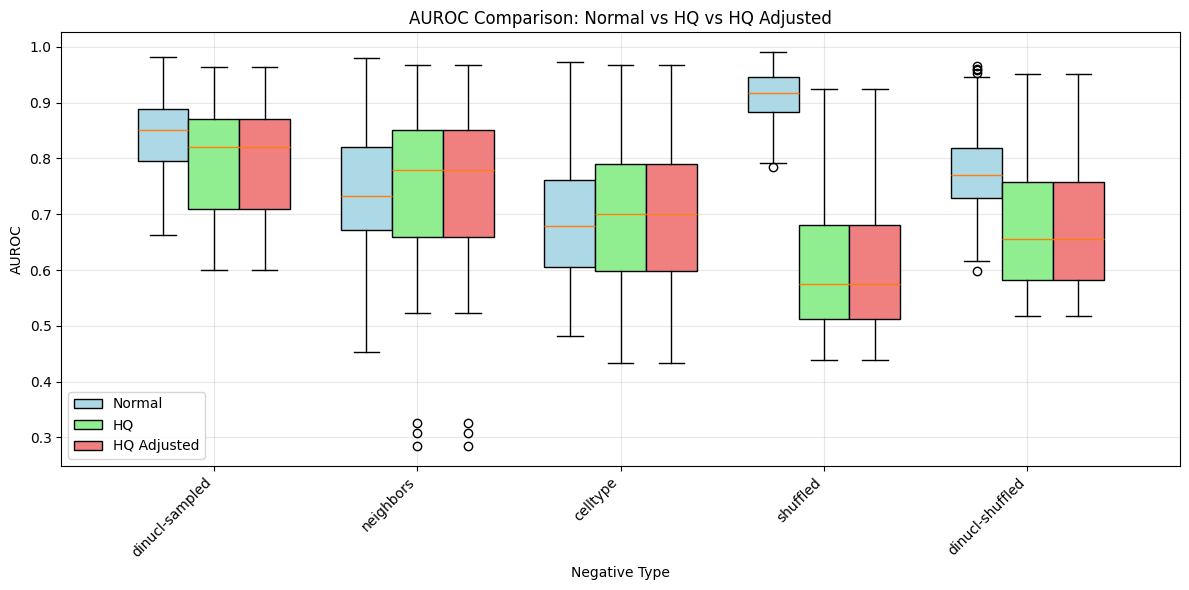

In [16]:
# Plot MCC comparison across normal, HQ, and HQ_adjusted versions
plot_metric_comparison(results_df, metric='AUROC')

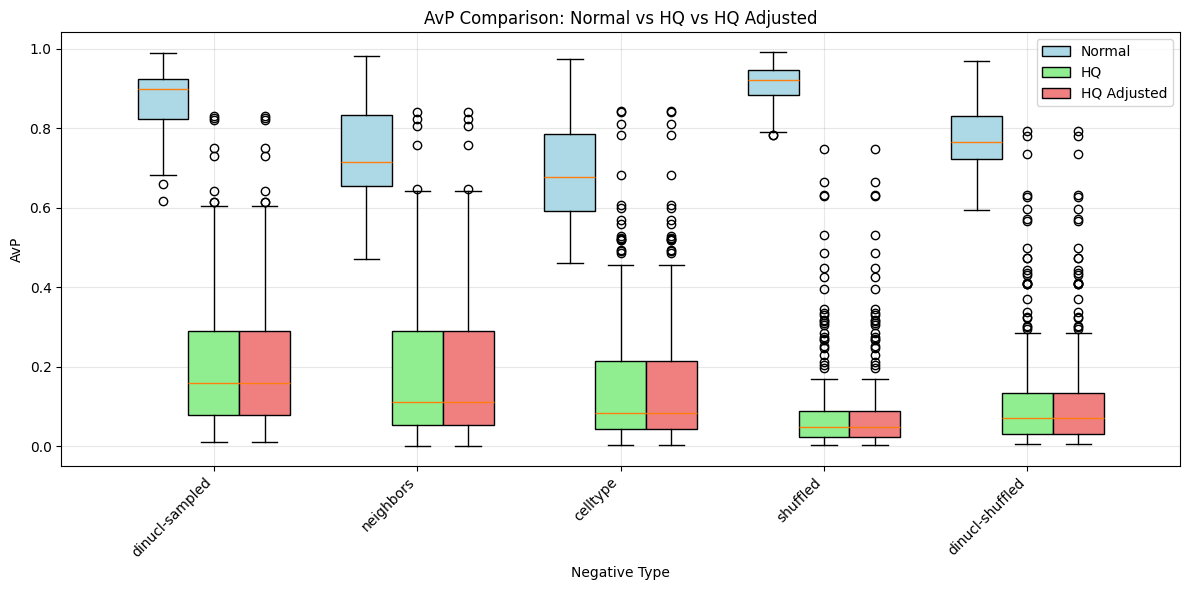

In [17]:
# Plot MCC comparison across normal, HQ, and HQ_adjusted versions
plot_metric_comparison(results_df, metric='AvP')

In [ ]:
# results_df.to_pickle(os.path.join(output_folder, "calibration_results.pkl"))

In [27]:
color_list = [
    "#ff595e", "#ff924c", "#ffca3a", "#c5ca30", "#8ac926",
    "#52a675", "#1982c4", "#4267ac", "#6a4c93", "#b5a6c9"
]

neg_mode_labels = {
    'dinucl-sampled': 'G-S',
    'dinucl-shuffled': 'DN-SH',
    'neighbors': 'NB-S',
    'shuffled': 'SH',
    'motif': "PWM",
    'celltype': 'CL',
    'HQ training': 'HQ'
}

In [26]:
results_df.neg_type.unique()

array(['dinucl-sampled', 'neighbors', 'celltype', 'shuffled',
       'dinucl-shuffled'], dtype=object)

In [20]:
from matplotlib.patches import Patch
import seaborn as sns

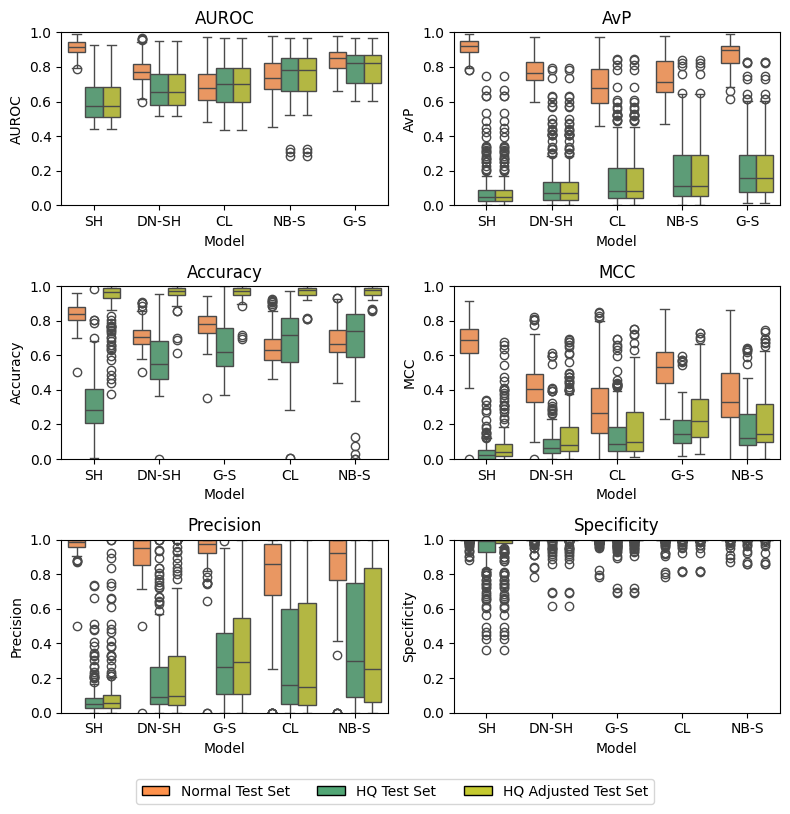

In [28]:
# Define the metrics to plot
# (same list as before; these are the *base* metric names, not the HQ-adjusted ones)
metrics = [
    ('test_scores_AUROC', 'AUROC_value', 'auroc_metric'),
    ('test_scores_AvP', 'Average_Precision_value', 'Average_Precision_metric'),
    ('test_scores_Accuracy', 'Accuracy_value', 'Accuracy_metric'),
    ('test_scores_MCC', 'Matthews_Correlation_value', 'Matthews_Correlation_metric'),
    ('test_scores_Precision', 'Precision_value', 'Precision_metric'),
    ('test_scores_Specificity', 'Specificity_value', 'Specificity_metric'),
]

fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.flatten()

palette_standard = {
    'Standard': color_list[1],
    'HQ': color_list[5],
    'HQ adjusted': color_list[3],
}

for idx, (metric_name, value_col, metric_col) in enumerate(metrics):
    ax = axes[idx]

    # base metric short name, e.g. "AUROC"
    base = metric_name.replace("test_scores_", "")

    # column names in results_df
    std_col = metric_name                           # e.g. test_scores_AUROC
    hq_col = f"test_scores_HQ_{base}"               # e.g. test_scores_HQ_AUROC
    hq_adj_col = f"test_scores_HQ_adjusted_{base}"  # e.g. test_scores_HQ_adjusted_AUROC

    value_vars = []
    mapping = {}

    if std_col in results_df.columns:
        value_vars.append(std_col)
        mapping[std_col] = 'Standard'

    if hq_col in results_df.columns:
        value_vars.append(hq_col)
        mapping[hq_col] = 'HQ'

    if hq_adj_col in results_df.columns:
        value_vars.append(hq_adj_col)
        mapping[hq_adj_col] = 'HQ adjusted'

    # melt to long format
    melted_data = pd.melt(
        results_df.sort_values(by=['neg_type']),
        id_vars=['neg_type', "cell_line", 'TF'],
        value_vars=value_vars,
        var_name=metric_col,
        value_name=value_col
    )

    # convert tensors / objects to float
    melted_data[value_col] = melted_data[value_col].apply(
        lambda x: float(x.detach().cpu().numpy()) if hasattr(x, "detach") else float(x)
    )

    # map metric names to labels (Standard / HQ / HQ adjusted)
    melted_data[metric_col] = melted_data[metric_col].map(mapping)

    # map neg_mode labels
    melted_data = melted_data.rename(columns={"neg_type": "neg_mode"})
    melted_data['neg_mode_short'] = melted_data['neg_mode'].map(neg_mode_labels)

    # order categories by *HQ* performance if available, else by Standard
    order_source_label = 'HQ' if 'HQ' in melted_data[metric_col].unique() else 'Standard'
    order_source = melted_data[melted_data[metric_col] == order_source_label]

    mean_per_mode = (
        order_source
        .groupby("neg_mode_short")[value_col]
        .mean()
        .sort_values(ascending=True)
    )
    neg_mode_order_metric = mean_per_mode.index.tolist()

    melted_data["neg_mode_short"] = pd.Categorical(
        melted_data["neg_mode_short"],
        categories=neg_mode_order_metric,
        ordered=True
    )

    # Create boxplot with 3 hues where available
    sns.boxplot(
        data=melted_data,
        x='neg_mode_short',
        y=value_col,
        hue=metric_col,
        palette=palette_standard,
        dodge=True,
        ax=ax
    )

    ax.set_xlabel("Model")
    ax.set_ylabel(base.replace('_', ' '))
    ax.set_title(f"{base.replace('_', ' ')}")
    ax.set_ylim(0, 1)

    if ax.get_legend():
        ax.get_legend().remove()

# Shared legend: Standard, HQ, HQ adjusted
legend_handles = [
    Patch(facecolor=palette_standard['Standard'], edgecolor='black', label='Normal Test Set'),
    Patch(facecolor=palette_standard['HQ'], edgecolor='black', label='HQ Test Set'),
    Patch(facecolor=palette_standard['HQ adjusted'], edgecolor='black', label='HQ Adjusted Test Set'),
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
